# **"Internship Task by Decodelabs"**

- **Intership Duration : 25th-April-2026 - 25th-May-2026**

- **Project : 3**

     **Task : 1 - Data Collection & Data Understanding**

     **Task : 2 - Data Cleaning & Preprocessing**

     **Task : 3 - Exploratory Data Analysis (EDA)**


     **Task : 4 - Data Visualization**

     **Task : 5 - Predictive Model or Insight Project**

- **Data Source : From Kaggle**

- **DataSet Name : House Price Prediction**

- **Domain : Data Science**

- **Submitted By : Palwasha Mushtaq**

# **Data Introduction**

**The house price dataset contains information about different properties and their selling prices. The dataset includes 2000 records and 10 columns representing various house features such as area, number of bedrooms, bathrooms, floors, construction year, location, condition, garage availability, and price.**

**The purpose of this dataset is to analyze house characteristics and understand how different factors may influence property prices. The dataset contains both numerical and categorical variables, making it suitable for statistical analysis, data visualization, and machine learning regression tasks.**

**By exploring this dataset, patterns, distributions, and relationships between housing features and prices can be identified to gain insights into the real estate market.**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# **Load Data**

In [2]:
df = pd.read_csv('House Price Prediction Dataset.csv')
df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


**Data Overview**

In [3]:
print('DATA SHAPE:\n', df.shape)
print('=========================================================================================================')
print('DATA COLUMNS:\n', df.columns)
print('=========================================================================================================')
print('DATA INFO:\n', df.info())
print('=========================================================================================================')
print('DESCRIPTION STATISTICS SUMMARY:\n', df.describe())
print('=========================================================================================================')

DATA SHAPE:
 (2000, 10)
DATA COLUMNS:
 Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB
DATA INFO:
 None
DESCRIPTION STATISTICS SUMMARY:
                 Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.

**The dataset contains 2000 rows and 10 columns. Each row represents a house with different features such as area, bedrooms, bathrooms, location, and price. Also it contains both numerical and categorical variables. Numerical columns include Area, Bedrooms, Bathrooms, Floors, YearBuilt, and Price, while Location, Condition, and Garage are categorical features.**

**DESCRIPTION STATISTICS SUMMARY SHOWS THE FOLLOWING RESULT:**

- The average house area is around 2786 square feet.
- Most houses contain 2 to 4 bedrooms and multiple bathrooms.
- The average house price is approximately 537,676.
- The minimum house price is 50,005 while the maximum reaches 999,656.
- The wide standard deviation in Price indicates high variation in house prices.
- Houses were built between 1900 and 2023, showing both old and modern properties.

**Check Missing Values**

In [4]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

**Check Duplicate Values**

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop('Id', axis=1, inplace=True)
print(df)

      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0     1360         5          4       3       1970  Downtown  Excellent   
1     4272         5          4       3       1958  Downtown  Excellent   
2     3592         2          2       3       1938  Downtown       Good   
3      966         4          2       2       1902  Suburban       Fair   
4     4926         1          4       2       1975  Downtown       Fair   
...    ...       ...        ...     ...        ...       ...        ...   
1995  4994         5          4       3       1923  Suburban       Poor   
1996  3046         5          2       1       2019  Suburban       Poor   
1997  1062         5          1       2       1903     Rural       Poor   
1998  4062         3          1       2       1936     Urban  Excellent   
1999  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  
0        No  149919  
1        No  424998  
2        No  266746  
3       Yes

**After checked the missing values and duplicate values in the dataset it is showed that this data doesnot contain any missing and duplicated values.**

**Exploratory Data Analysis(EDA)**

- **Statistic Data Analysis**

In [7]:
print('UNIQUE VALUES IN CONDITION COLUMN:')
print(df['Condition'].value_counts())

UNIQUE VALUES IN CONDITION COLUMN:
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64


In [8]:
df['Bedrooms'].value_counts()

Bedrooms
1    418
3    406
4    405
5    403
2    368
Name: count, dtype: int64

In [9]:
df['Bathrooms'].value_counts() 

Bathrooms
3    524
4    521
2    494
1    461
Name: count, dtype: int64

In [10]:
df['Garage'].value_counts()

Garage
No     1038
Yes     962
Name: count, dtype: int64

**Data Visualization**

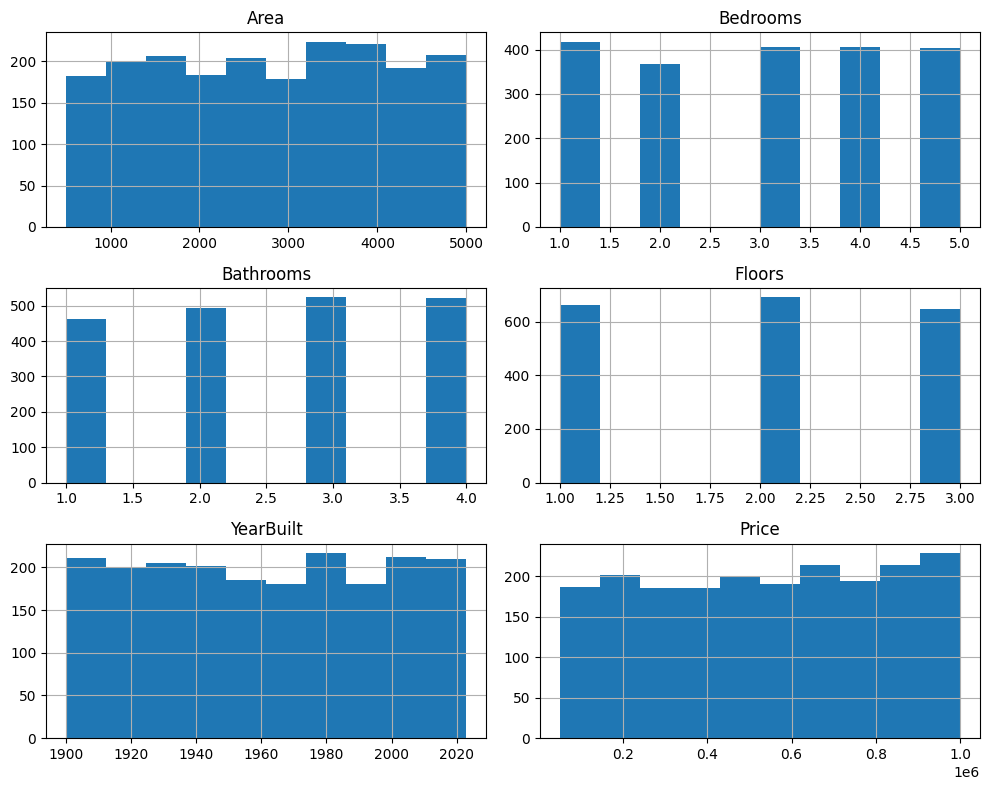

In [11]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

- **The distribution of house area appears fairly balanced across different ranges, indicating that the dataset contains both small and large houses without extreme concentration in a single area range.**
- **Most houses contain between 1 and 5 bedrooms, with frequencies distributed relatively evenly across all bedroom categories.**
- **The number of bathrooms is spread across different categories, showing variation in house sizes and facilities.**
- **Houses mainly contain 1 to 3 floors, with 2-floor houses appearing slightly more common.**
- **The houses were built between 1900 and 2023, indicating a mix of old and modern properties in the dataset.**
- **House prices are distributed across a wide range, showing significant variation in property values within the dataset.**

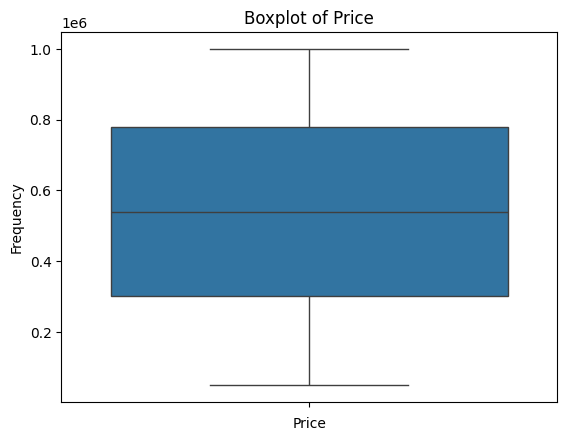

In [12]:
sns.boxplot(df['Price'])
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**The boxplot of Price shows the distribution of house prices in the dataset. The median price is around 540,000, while the prices are spread over a wide range. The absence of significant outliers indicates that the dataset does not contain extremely unusual house prices, suggesting a relatively balanced distribution of property values.**

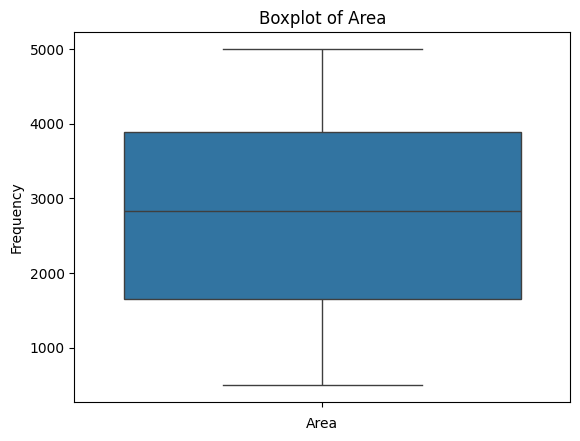

In [13]:
sns.boxplot(df['Area'])
plt.title('Boxplot of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.show()

**The boxplot of Area shows the distribution of house sizes in the dataset. The median area is around 3000 square yards, while the area values are spread across a wide range. The absence of significant outliers indicates that the dataset does not contain extremely unusual house sizes, suggesting a relatively balanced distribution of properties..**

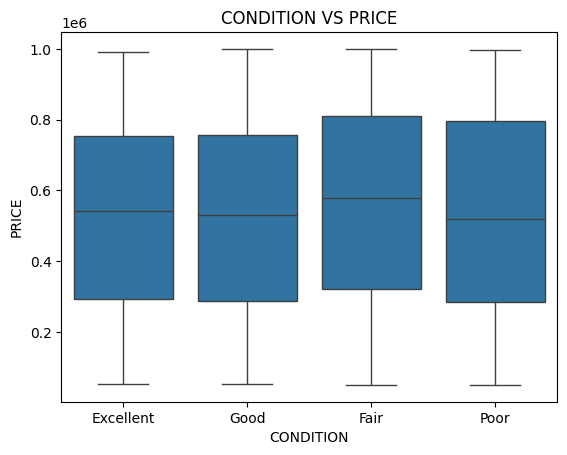

In [14]:
sns.boxplot(x='Condition', y='Price', data=df)
plt.title("CONDITION VS PRICE")
plt.xlabel("CONDITION")
plt.ylabel("PRICE")
plt.show()

**The above graph shows that House prices across different conditions (Excellent, Good, Fair, Poor) are almost similar. The median prices and overall distribution overlap strongly, showing that house condition has a weak impact on price in this dataset.**

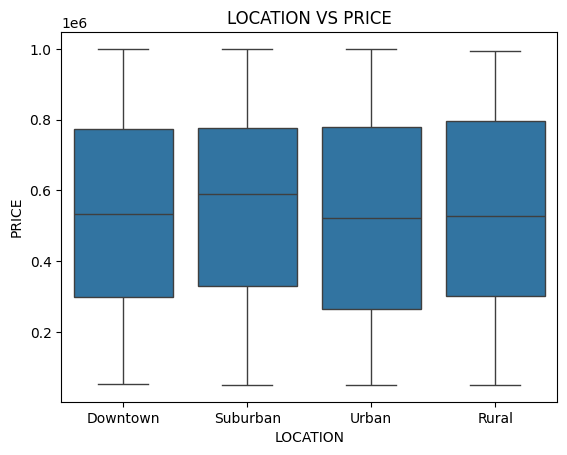

In [15]:
sns.boxplot(x='Location', y='Price', data=df)
plt.title('LOCATION VS PRICE')
plt.xlabel('LOCATION')
plt.ylabel('PRICE')
plt.show()

**The above graph shows that House prices across different locations (Downtown, Suburban, Urban, Rural) also show very similar distributions. Although Suburban areas are slightly higher in some cases, overall location does not strongly affect price in this dataset.**

**Correalation Analysis**

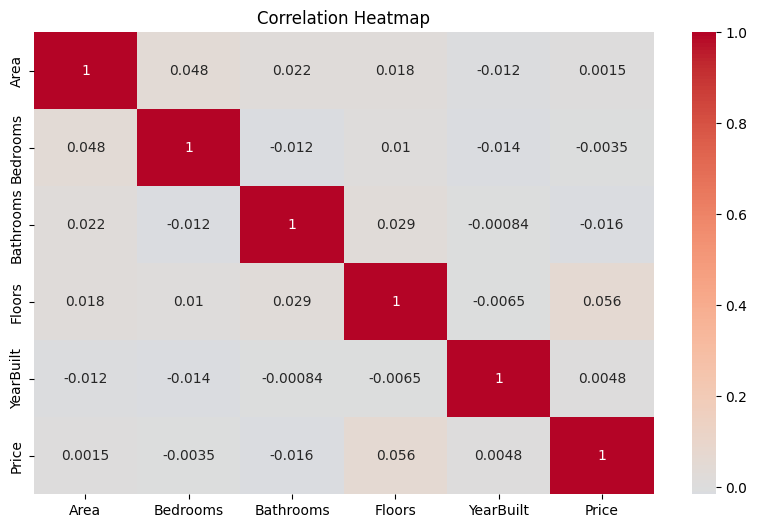

In [16]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

**The correlation heatmap shows the relationship between numerical features and house prices. Most variables have very weak correlations with Price, indicating that no single numerical feature strongly influences house prices in this dataset. Floors shows a slightly positive relationship with Price, while other features such as Bedrooms, Bathrooms, Area, and YearBuilt have correlations close to zero.**

**Overall, the dataset does not show strong linear relationships between variables, which suggests that advanced models like Random Forest Regressor may perform better than Linear Regression.**

**Encoding**

In [17]:
le = LabelEncoder()
df["Garage"] = le.fit_transform(df["Garage"])
print('LABLE ENCODING (GARAGE)')
print(df)

LABLE ENCODING (GARAGE)
      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0     1360         5          4       3       1970  Downtown  Excellent   
1     4272         5          4       3       1958  Downtown  Excellent   
2     3592         2          2       3       1938  Downtown       Good   
3      966         4          2       2       1902  Suburban       Fair   
4     4926         1          4       2       1975  Downtown       Fair   
...    ...       ...        ...     ...        ...       ...        ...   
1995  4994         5          4       3       1923  Suburban       Poor   
1996  3046         5          2       1       2019  Suburban       Poor   
1997  1062         5          1       2       1903     Rural       Poor   
1998  4062         3          1       2       1936     Urban  Excellent   
1999  2989         5          1       3       1903  Suburban       Fair   

      Garage   Price  
0          0  149919  
1          0  424998  
2     

In [18]:
df= pd.get_dummies(df, columns=['Condition','Location'], dtype=int)
print('\n ONE-HOT ENCODING(CONDITION,LOCATION)')
print(df.head())


 ONE-HOT ENCODING(CONDITION,LOCATION)
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Garage   Price  \
0  1360         5          4       3       1970       0  149919   
1  4272         5          4       3       1958       0  424998   
2  3592         2          2       3       1938       0  266746   
3   966         4          2       2       1902       1  244020   
4  4926         1          4       2       1975       1  636056   

   Condition_Excellent  Condition_Fair  Condition_Good  Condition_Poor  \
0                    1               0               0               0   
1                    1               0               0               0   
2                    0               0               1               0   
3                    0               1               0               0   
4                    0               1               0               0   

   Location_Downtown  Location_Rural  Location_Suburban  Location_Urban  
0                  1               0   

- **Split Data For Training and Testing**

In [19]:
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("TRAINING DATA:\n", X_train)
print("TESTING DATA:\n", X_test)

TRAINING DATA:
       Area  Bedrooms  Bathrooms  Floors  YearBuilt  Garage  \
968   4483         4          4       3       1933       0   
240   1062         3          3       1       1970       0   
819   1422         3          4       1       1993       1   
692   2658         2          3       1       1972       1   
420   3286         2          4       1       1981       1   
...    ...       ...        ...     ...        ...     ...   
1130  3483         5          3       3       1931       1   
1294  1747         3          3       2       1941       1   
860   1484         2          3       3       1973       0   
1459  3456         5          4       1       1955       1   
1126  1682         2          1       3       2006       0   

      Condition_Excellent  Condition_Fair  Condition_Good  Condition_Poor  \
968                     1               0               0               0   
240                     0               0               1               0   
819     

- **Apply Standard Scaler**

In [20]:

standard_scaler =StandardScaler()

standard_scaled= standard_scaler.fit_transform(X[['Area', 'Bedrooms','Bathrooms','Floors','YearBuilt']])
print('STANDARD_SCALER_OUTPUT')
print(pd.DataFrame(standard_scaled, columns=['Area', 'Bedrooms','Bathrooms','Floors','YearBuilt']))

STANDARD_SCALER_OUTPUT
          Area  Bedrooms  Bathrooms    Floors  YearBuilt
0    -1.101471  1.401791   1.305568  1.244151   0.238155
1     1.147485  1.401791   1.305568  1.244151  -0.095942
2     0.622317 -0.704581  -0.498326  1.244151  -0.652770
3    -1.405759  0.699667  -0.498326  0.008035  -1.655061
4     1.652574 -1.406705   1.305568  0.008035   0.377363
...        ...       ...        ...       ...        ...
1995  1.705091  1.401791   1.305568  1.244151  -1.070391
1996  0.200638  1.401791  -0.498326 -1.228081   1.602385
1997 -1.331618  1.401791  -1.400273  0.008035  -1.627219
1998  0.985301 -0.002457  -1.400273  0.008035  -0.708453
1999  0.156616  1.401791  -1.400273  1.244151  -1.627219

[2000 rows x 5 columns]


**StandardScaler is applied to numerical features like 'Area', 'Bedrooms','Bathrooms','Floors','YearBuilt' to normalize their values. This ensures that all features are on a similar scale, which helps the model perform more effectively and improves convergence.**

# **Model Building**

- **Linear Regression Model**

In [21]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred_lr = lr.predict(X_test)
print(y_pred_lr)

[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512 521375.92025826 523320.18080583 578133.64353335
 545899.64738458 577368.69940644 549359.90237922 583802.8656311
 511024.20843161 527181.17287186 502178.93122353 563657.42139779
 533851.47058016 557566.45545641 578893.4890812  522197.01288502
 535945.37429884 520333.81440515 520145.76012635 589984.6964629
 570910.91251258 530657.68307139 524849.79926253 533833.03412407
 517535.08657939 489462.64631857 471135.44970754 532885.36922583
 559703.53345149 566918.76753933 505186.85760171 504126.65238569
 566525.93875815 587039.42913431 533334.54147469 503067.97932305
 488794.10065586 540580.91705316 538165.7543287  538208.1073811
 539782.8193264  574195.17961934 551957.63060142 537147.22385255
 531554.19942009 528480.27403638 515181.27688738 549393.77262824
 567112.62323004 545742.10255364 516610.31460763 540624.51409841
 572646.45505536 503331.46804219 506163.52635772 515153.14850925
 545927.35223535 498381.43971

**Random Forest Regressor**

In [23]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
y_pred_rfr = rfr.predict(X_test)
print(y_pred_rfr)

[627386.99 466651.61 560187.97 478100.09 549809.94 559667.41 517842.33
 590369.72 635366.87 625946.42 483389.44 665291.6  534385.45 594195.8
 515966.4  473785.15 623405.74 595154.45 688510.87 444236.91 556884.15
 452557.27 366594.58 667491.56 422726.14 592594.74 426057.17 425136.66
 514340.94 561705.46 553931.19 627254.4  587208.87 588935.32 379377.51
 501946.65 606428.37 520793.79 555854.75 412675.04 510087.86 492285.95
 558609.27 442702.63 502310.05 543015.26 535522.79 420043.37 506019.1
 429051.21 501186.1  574724.36 608410.03 469265.48 548998.83 602246.33
 573220.69 457475.52 511738.71 495543.29 570800.49 602375.5  535674.54
 399677.16 587776.16 496988.25 529352.28 533167.45 478526.34 505043.17
 467395.04 614151.68 569179.58 500496.92 533656.21 627217.51 626782.41
 512043.78 346536.36 517754.55 493293.47 567526.97 438555.94 566539.19
 433864.73 524413.97 430622.29 478178.76 505860.31 586319.46 607639.94
 503586.98 404638.76 493307.9  556938.9  511930.36 558079.63 527214.88
 580693.

**Decision Tree Regressor**

In [25]:
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [26]:
y_pred_dtr = dtr.predict(X_test)
print(y_pred_dtr)

[109263. 764618. 939217. 485485. 577561. 891672.  69416. 201744. 974570.
 929793. 514838. 833103. 721844. 827981. 271738. 792476. 691157. 549344.
 996931. 346508. 733429. 135687. 419170. 904531. 294437. 585755. 354960.
 201168. 174698. 214340. 128743. 948407. 732561. 635009. 397509. 678420.
 974570. 782119. 503035. 375737. 150647. 764618. 517121. 977325. 965672.
 226978. 856903. 266897. 940965. 325333. 346753. 230697. 910513. 284729.
 782320. 890271. 974253. 112708. 745169. 540674. 493888. 453562. 558928.
 794314. 178145. 378624. 846240. 314531. 923055. 333453. 997176. 333453.
 833103. 226978. 860763. 974253. 669113.  77597.  92628. 141544. 511531.
 562164. 346753. 479767. 641759. 171449. 141257. 499704. 980728. 672186.
 846240. 317014.  77313. 325251. 161186. 957023. 965885. 716217. 796355.
 724075. 218769. 168384. 751486. 416056. 184974. 411799. 325871. 732561.
 655950. 838049. 634819. 695115. 214340. 333453. 325536. 467876. 712600.
 178568. 961118.  57176. 676517. 730047.  74220. 15

# **Evaluation Metrics**

In [27]:
print('Linear Regression Metrics')
lr_mae = mean_absolute_error(y_test, y_pred_lr)
print(lr_mae)
lr_mse = mean_squared_error(y_test, y_pred_lr)
print(lr_mse)
lr_rmse = np.sqrt(lr_mse)
print(lr_rmse)
lr_r2 = r2_score(y_test, y_pred_lr)
print(lr_r2)
print('========================================================================================================')
print('Random Forest Regression Metrics')
rfr_mae = mean_absolute_error(y_test, y_pred_rfr)
print(rfr_mae)
rfr_mse = mean_squared_error(y_test, y_pred_rfr)
print(rfr_mse)
rfr_rmse = np.sqrt(rfr_mse)
print(rfr_rmse)
rfr_r2 = r2_score(y_test, y_pred_rfr)
print(rfr_r2)
print('========================================================================================================')
print('Decision Tree Regression Metrics') 
dtr_mae = mean_absolute_error(y_test, y_pred_dtr)
print(dtr_mae)
dtr_mse = mean_squared_error(y_test, y_pred_dtr)
print(dtr_mse)
dtr_rmse = np.sqrt(dtr_mse)
print(dtr_rmse)
dtr_r2 = r2_score(y_test, y_pred_dtr)
print(dtr_r2)     


Linear Regression Metrics
243241.97758826384
78321466146.0328
279859.72583784326
-0.006717808430749761
Random Forest Regression Metrics
253075.57275
85605579335.0809
292584.31149855064
-0.10034535177074955
Decision Tree Regression Metrics
338416.8
169259176944.51
411411.20177325024
-1.175600586340666


**Matrix Comparsion Tree**

In [28]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest','Decision Tree'],
    
    'MAE': [lr_mae, rfr_mae, dtr_mae],
    
    'MSE': [lr_mse, rfr_mse,dtr_mse],
    
    'RMSE': [lr_rmse, rfr_rmse, dtr_rmse],
    
    'R2 Score': [lr_r2,  rfr_r2,dtr_r2]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,243241.977588,7.832147e+10,279859.725838,-0.006718
1,Random Forest,253075.572750,8.560558e+10,292584.311499,-0.100345
2,Decision Tree,338416.800000,1.692592e+11,411411.201773,-1.175601


# **Model Comparsion Summary**

**The model comparison table evaluates the performance of Linear Regression, Random Forest Regressor, and Decision Tree Regressor using MAE, MSE, RMSE, and R² Score.**

**Among all models, Linear Regression performs slightly better with the lowest MAE, MSE, and RMSE values, indicating comparatively smaller prediction errors. Random Forest shows slightly higher error values, while Decision Tree performs the worst with extremely high error metrics.**

**The negative R² scores for all models indicate that the models are not fitting the dataset effectively and are performing worse than a simple mean-based prediction. This suggests that the dataset may not contain strong relationships between features and house prices, which is also supported by the weak correlations observed in the heatmap analysis.**

**Overall, Linear Regression provides the best performance among the tested models, although the overall predictive performance of all models remains weak.**

# **Conclusion**



# **OVERALL SUMMARY**

This project focuses on predicting house prices using Machine Learning regression models. The dataset contains 2000 house records with different property-related features such as area, number of bedrooms, bathrooms, floors, construction year, location, condition, garage availability, and house price.

The main objective of this project was to analyze the relationship between house features and property prices and build predictive models capable of estimating house prices accurately.

Several data preprocessing techniques, exploratory data analysis (EDA), feature engineering methods, and regression algorithms were applied to understand the dataset and evaluate model performance.

**BUSINESS PROBLEM**

Real estate companies, property dealers, and buyers often face difficulty in estimating accurate house prices because property values depend on multiple factors such as area, location, condition, and house facilities.

Manual price estimation can be time-consuming and inconsistent. Therefore, businesses require a data-driven solution that can analyze housing features and predict property prices more efficiently.

**KEY BUSINESS CHALLENGES**
 - Understanding which house features influence prices
 - Handling both numerical and categorical data
 - Building an accurate prediction model for house prices
 - Comparing different machine learning regression models
 - Analyzing whether relationships between features and prices are linear or non-linear

**SOLUTION**

A machine learning-based regression system was developed to predict house prices using different housing features.

**The project involved:**

 - Data preprocessing
 - Exploratory Data Analysis (EDA)
 - Feature encoding
 - Feature scaling
 - Model training
 - Performance evaluation

**Three regression models were trained and compared:**

 - Linear Regression
 - Random Forest Regressor
 - Decision Tree Regressor

**STEPS PERFORMED**
1. Data Cleaning & Preprocessing
 - Checked dataset shape and structure
 - Verified data types
 - Checked missing values
 - Checked duplicate records
 - Dropped unnecessary Id column

**Findings:**
 - No missing values found
 - No duplicate values found
 - Dataset was already clean and balanced

2. Exploratory Data Analysis (EDA)

Different visualizations and statistical analysis techniques were applied to understand the dataset.

**Key observations:**
 - House areas were fairly distributed without extreme concentration
 - Bedrooms ranged from 1–5 with balanced frequency
 - Bathrooms showed balanced variation across houses
 - Most houses contained 1–3 floors
 - Houses were built between 1900–2023
 - Property prices varied significantly across the dataset

 **Boxplot Analysis:**
 - No significant outliers found in Area
 - No significant outliers found in Price
 
  **Boxplot Analysis:**
 - House prices varied across different Conditions
 - House prices varied across different Locations

 **Correlation Heatmap:**
Most numerical variables showed weak linear relationships with Price
Floors showed slightly positive correlation with Price
Weak correlations suggested that advanced non-linear models may perform better

3. Feature Encoding
 - Label Encoding:Applied on:Garage column
 - One-Hot Encoding Applied on: Condition,Location

This converted categorical features into numerical format suitable for machine learning models.

4. Feature Scaling

Applied StandardScaler on numerical features:

 - Area,Bedrooms,Bathrooms,Floors,YearBuilt

Scaling normalized the feature ranges and improved model training consistency.

5. Train-Test Split

Dataset was divided into:

 - 80% Training Data
 - 20% Testing Data

Training data was used to train the models while testing data was used for evaluation.

**MODELS TRAINED**
1. Linear Regression

A simple regression model used to identify linear relationships between features and house prices.

2. Random Forest Regressor

An ensemble learning model capable of handling non-linear relationships and feature interactions.

3. Decision Tree Regressor

A tree-based regression model that predicts values through decision rules and feature splitting.

**MODEL EVALUATION**
 - Model	MAE	RMSE	R² Score
 
**KEY INSIGHTS (BUSINESS ANALYSIS)**
 - The dataset showed weak linear relationships between features and house prices.
 - Traditional Linear Regression did not perform well because housing prices may depend on complex non-linear relationships.
 - Decision Tree Regressor showed the poorest performance due to overfitting and unstable predictions.
 - Random Forest performed slightly better in capturing complex patterns but still struggled because of weak feature relationships.
 - Features such as location, condition, and floors showed some influence on prices, while other features had weak predictive power.
 - The dataset may require additional meaningful features such as:
Nearby facilities
Property age
Market demand
Economic indicators
Interior quality
Neighborhood ratings

**RECOMMENDATIONS**
 - Add more relevant real estate features to improve prediction accuracy
 - Perform advanced feature engineering
 - Try hyperparameter tuning for better optimization
 - Use advanced boosting models such as:
  XGBoost
  Gradient Boosting
  CatBoost
 - Apply feature selection techniques
Increase dataset size for better learning capability
 - Use cross-validation for more reliable model evaluation

**FINAL CONCLUSION**

**In this project, different machine learning regression models were developed to predict house prices using features such as area, bedrooms, bathrooms, floors, year built, location, condition, and garage availability.**

**The dataset was first explored through statistical analysis and exploratory data analysis (EDA). Histograms, boxplots, scatterplots, and correlation heatmaps were used to understand the distribution of variables, detect outliers, and analyze relationships between features and house prices. The analysis showed that the dataset contained balanced distributions with no significant outliers, while most numerical variables had weak correlations with the target variable.**

**Data preprocessing techniques including encoding and feature scaling were applied before model training. Three regression models — Linear Regression, Random Forest Regressor, and Decision Tree Regressor — were trained and evaluated using MAE, MSE, RMSE, and R² Score.**

**Among the tested models, Linear Regression achieved comparatively better performance with lower prediction errors than Random Forest and Decision Tree. However, all models produced negative R² scores, indicating weak predictive performance and suggesting that the dataset does not contain strong linear or meaningful relationships between features and house prices.**

**Overall, the project demonstrates the complete workflow of a house price prediction system including data preprocessing, visualization, statistical analysis, model building, and evaluation. The results indicate that additional relevant features, better feature engineering, or a more informative dataset may improve prediction accuracy in future work.**